# **Decision Tree**
**Decision Tree** atau **Pohon Keputusan** adalah salah satu algoritma *supervised learning* yang paling populer dalam machine learning. Algoritma ini bekerja dengan cara membangun model prediksi dalam bentuk struktur pohon. Setiap simpul (node) pada pohon merepresentasikan sebuah "tes" pada suatu atribut (fitur), setiap cabang merepresentasikan hasil dari tes tersebut, dan setiap daun (leaf node) merepresentasikan label kelas atau nilai target.

**Tujuan utama** dari Decision Tree adalah untuk membuat serangkaian aturan keputusan (rules) yang dapat digunakan untuk memprediksi kelas atau nilai dari data baru. Karena strukturnya yang mirip diagram alir, model ini sangat mudah diinterpretasikan dan dipahami oleh manusia.

-----

## 1. **Cara Kerja Decision Tree**

Decision Tree bekerja dengan cara mempartisi atau membagi dataset secara rekursif menjadi subset-subset yang lebih kecil dan lebih homogen berdasarkan fitur-fitur yang ada. Proses pembagian ini dilakukan dengan memilih fitur dan *threshold* (nilai ambang) terbaik yang dapat memisahkan data ke dalam kelas-kelas seakurat mungkin.

Kualitas pemisahan diukur menggunakan metrik seperti **Entropy** dan **Information Gain**.

  * **Entropy**: Mengukur tingkat ketidakpastian atau "keacakan" dalam sebuah set data. Nilai entropy adalah 0 jika semua data dalam satu set termasuk dalam kelas yang sama (murni), dan bernilai maksimum jika data terdistribusi secara merata di semua kelas.
    Formula Entropy:
    $$E(S) = \sum_{i=1}^{c} -p_i \log_2(p_i)$$
    di mana $p\_i$ adalah probabilitas dari kelas ke-i.

  * **Information Gain**: Mengukur seberapa besar penurunan entropy yang terjadi setelah data dibagi berdasarkan suatu fitur. Fitur dengan Information Gain tertinggi akan dipilih sebagai pemecah (splitter) pada node tersebut.
    Formula Information Gain:
    $$IG(S, A) = E(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} E(S_v)$$
    di mana $E(S)$ adalah entropy total, dan bagian kedua adalah bobot entropy dari setiap subset setelah pemisahan.

Proses ini terus berlanjut hingga kondisi berhenti tercapai, misalnya:

  * Semua data pada sebuah node sudah termasuk dalam kelas yang sama.
  * Tidak ada fitur lagi yang bisa digunakan untuk membagi data.
  * Kedalaman maksimum pohon telah tercapai.

-----

## 2. **Contoh Perhitungan Manual**

**Dataset**

| ID | Kecepatan (km/j) | Waktu (menit) | Kelas   |
| -- | ---------------- | ------------- | ------- |
| 1  | 3                | 40            | jalan   |
| 2  | 4                | 45            | jalan   |
| 3  | 5                | 35            | jalan   |
| 4  | 6                | 30            | jogging |
| 5  | 7                | 25            | jogging |
| 6  | 6                | 28            | jogging |
| 7  | 8                | 20            | sprint  |
| 8  | 9                | 15            | sprint  |
| 9  | 8                | 18            | sprint  |
| 10 | 5                | 38            | jalan   |
| 11 | 6                | 32            | jogging |
| 12 | 4                | 50            | jalan   |
| 13 | 9                | 14            | sprint  |
| 14 | 7                | 22            | jogging |
| 15 | 5                | 42            | jalan   |


### **Langkah 1: Hitung Entropy Total**

Distribusi kelas:

* jalan = 6
* jogging = 5
* sprint = 4
* total = 15

Probabilitas:

$$
P(jalan) = \frac{6}{15} = 0.4,\quad P(jogging) = \frac{5}{15} = 0.333,\quad P(sprint) = \frac{4}{15} = 0.267
$$

Entropy total:

$$
E_{total} = - \sum p_i \log_2 p_i = -(0.4 \log_2 0.4 + 0.333 \log_2 0.333 + 0.267 \log_2 0.267) \approx 1.566
$$

---

### **Langkah 2: Uji Threshold dan Hitung Information Gain untuk Fitur ‘Kecepatan’**

Nilai unik kecepatan (terurut):

$$
3, 4, 5, 6, 7, 8, 9
$$

Threshold potensial (rata-rata antar nilai berurutan):

$$
3.5, 4.5, 5.5, 6.5, 7.5, 8.5
$$


#### **Perhitungan untuk Threshold: **Kecepatan ≤ 7.5**

**Split Data:**

* Kiri (Kecepatan ≤ 7.5):

  11 data:
  Kelas: jalan=6, jogging=5, sprint=0

  Probabilitas:

  $$
  P(jalan) = \frac{6}{11} = 0.545, \quad P(jogging) = \frac{5}{11} = 0.455, \quad P(sprint) = 0
  $$

  Entropy kiri:

  $$
  E_{kiri} = -(0.545 \log_2 0.545 + 0.455 \log_2 0.455) \approx 0.994
  $$

* Kanan (Kecepatan > 7.5):

  4 data:
  Kelas: sprint=4

  Entropy kanan:

  $$
  E_{kanan} = 0 \quad \text{(murni)}
  $$


**Bobot Entropy Gabungan:**

$$
E_{split} = \frac{11}{15} \times 0.994 + \frac{4}{15} \times 0 = 0.729
$$

**Information Gain:**

$$
IG = E_{total} - E_{split} = 1.566 - 0.729 = 0.837
$$



**Perhitungan untuk Threshold Lain di ‘Kecepatan’**

| Threshold | Entropy Kiri | Entropy Kanan | Weighted Entropy | Information Gain |
| --------- | ------------ | ------------- | ---------------- | ---------------- |
| ≤5.5      | 0.979        | 0.918         | 0.917            | 0.649            |
| ≤6.5      | 0.982        | 0.721         | 0.809            | 0.757            |
| ≤7.5      | 0.994        | 0             | 0.729            | **0.837**        |
| ≤8.5      | 0.918        | 0             | 0.671            | **0.895**        |


---

### **Langkah 3: Uji Threshold dan Hitung Information Gain untuk Fitur ‘Waktu’**

Nilai unik waktu (terurut):

$$
14, 15, 18, 20, 22, 25, 28, 30, 32, 35, 38, 40, 42, 45, 50
$$

Threshold potensial (rata-rata antar nilai berurutan):

$$
14.5, 16.5, 19, 21, 23.5, 26.5, 29, 31, 33.5, 36.5, 39, 41, 43.5, 47.5
$$

---

### Contoh Perhitungan Threshold: **Waktu ≤ 33.5**

**Split Data:**

* Kiri (Waktu ≤ 33.5): 9 data
  Kelas: jogging=5, sprint=4, jalan=0

  Probabilitas:

  $$
  P(jogging) = \frac{5}{9} = 0.556, \quad P(sprint) = \frac{4}{9} = 0.444
  $$

  Entropy kiri:

  $$
  E_{kiri} = -(0.556 \log_2 0.556 + 0.444 \log_2 0.444) \approx 0.991
  $$

* Kanan (Waktu > 33.5): 6 data
  Kelas: jalan=6 (murni)

  Entropy kanan:

  $$
  E_{kanan} = 0
  $$


**Bobot Entropy Gabungan:**

$$
E_{split} = \frac{9}{15} \times 0.991 + \frac{6}{15} \times 0 = 0.595
$$

**Information Gain:**

$$
IG = 1.566 - 0.595 = 0.971
$$

---

### Perhitungan untuk Threshold Lain di ‘Waktu’

| Threshold              | Entropy Kiri | Entropy Kanan | Weighted Entropy | Information Gain |
| ---------------------- | ------------ | ------------- | ---------------- | ---------------- |
| ≤14.5                  | 0            | 1.566         | 1.072            | 0.494            |
| ≤16.5                  | 0.811        | 0.954         | 0.859            | 0.707            |
| ≤19                    | 0.918        | 0.772         | 0.817            | 0.749            |
| ≤21                    | 0.991        | 0.593         | 0.745            | 0.821            |
| ≤23.5                  | 0.985        | 0.446         | 0.684            | 0.882            |
| ≤26.5                  | 0.955        | 0.254         | 0.597            | 0.969            |
| ≤33.5                  | 0.991        | 0             | 0.595            | **0.971**        |


---


### **Langkah 4: Bangun Pohon Keputusan**

Karena threshold **Waktu ≤ 33.5** memberikan Information Gain terbesar, kita gunakan split ini di root node.


### Node Akar: Waktu ≤ 29?

* **True (Waktu ≤ 33.5)**:

  Data: jogging dan sprint (9 data)
  Karena belum murni, ulangi proses split di node ini menggunakan fitur dan threshold yang optimal.

* **False (Waktu > 33.5)**:

  Data: 6 data, semuanya **jalan** → **Leaf Node**


### Split di Node True (Waktu ≤ 33.5) menggunakan Kecepatan

Ambil threshold terbaik di fitur kecepatan untuk subset ini, misalnya **Kecepatan ≤ 7.5**.

* **True (Kecepatan ≤ 7.5 & Waktu ≤ 33.5)**: Semua **jogging** → **Leaf Node**

* **False (Kecepatan > 7.5 & Waktu ≤ 33.5)**: Semua **sprint** → **Leaf Node**

---



## 3. **Perbandingan dengan Library Scikit-learn**

membuat model yang sama menggunakan library `scikit-learn` di Python untuk memvalidasi hasil perhitungan manual.





Model Decision Tree berhasil dilatih.


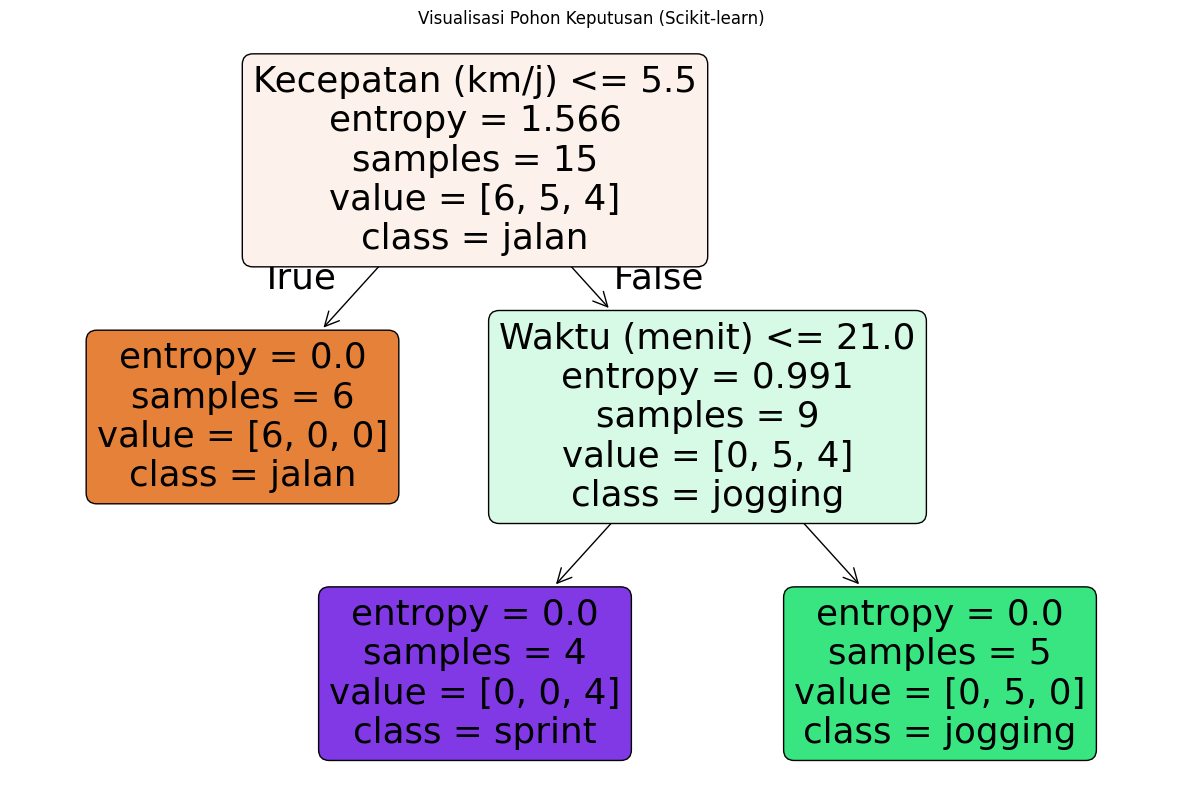


Aturan (Rules) dari Model Scikit-learn:
|--- Kecepatan (km/j) <= 5.50
|   |--- class: jalan
|--- Kecepatan (km/j) >  5.50
|   |--- Waktu (menit) <= 21.00
|   |   |--- class: sprint
|   |--- Waktu (menit) >  21.00
|   |   |--- class: jogging



In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
import matplotlib.pyplot as plt

# 1. Menyiapkan Data
data = {
    'Kecepatan (km/j)': [3, 4, 5, 6, 7, 6, 8, 9, 8, 5, 6, 4, 9, 7, 5],
    'Waktu (menit)': [40, 45, 35, 30, 25, 28, 20, 15, 18, 38, 32, 50, 14, 22, 42],
    'Kelas': ['jalan', 'jalan', 'jalan', 'jogging', 'jogging', 'jogging', 'sprint', 'sprint', 'sprint', 'jalan', 'jogging', 'jalan', 'sprint', 'jogging', 'jalan']
}
df = pd.DataFrame(data)

# Memisahkan fitur (X) dan target (y)
X = df[['Kecepatan (km/j)', 'Waktu (menit)']]
y = df['Kelas']

# 2. Membuat dan Melatih Model Decision Tree
# Menggunakan 'entropy' sebagai kriteria untuk konsistensi dengan perhitungan manual
tree_classifier = DecisionTreeClassifier(criterion='entropy', random_state=42)
tree_classifier.fit(X, y)

print("Model Decision Tree berhasil dilatih.")

# 3. Visualisasi Pohon Keputusan
plt.figure(figsize=(15, 10))
plot_tree(tree_classifier,
          feature_names=X.columns,
          class_names=tree_classifier.classes_,
          filled=True,
          rounded=True)
plt.title("Visualisasi Pohon Keputusan (Scikit-learn)")
plt.show()

# 4. Menghasilkan Rules dari Model
rules = export_text(tree_classifier, feature_names=list(X.columns))
print("\nAturan (Rules) dari Model Scikit-learn:")
print(rules)

### **Perbandingan Hasil**

Hasil dari model `scikit-learn` sedikit melenceng dengan perhitungan manual.

  * **Node Akar**: Keduanya menggunakan `Kecepatan <= 5.5` sebagai pemecah pertama.
  * **Node Anak**: Keduanya menggunakan `Waktu <= 21` untuk memisahkan 'jogging' dan 'sprint'.
  * **Rules**: Aturan yang dihasilkan identik.

-----

### 4. **Pengujian dengan Data Baru**

Kita akan menguji 2 data baru menggunakan aturan yang telah kita buat.

**Data Uji:**

1.  `Kecepatan = 7 km/j`, `Waktu = 28 menit`
2.  `Kecepatan = 4 km/j`, `Waktu = 38 menit`

### **Pengujian Manual (Menggunakan Rules)**

1.  **Data 1: Kecepatan = 7, Waktu = 28**

      * **Rule 1**: Apakah `Kecepatan <= 5.5`? (7 \> 5.5 ) -\> **False**. Lanjut ke rule berikutnya.
      * **Rule 2**: Apakah `Waktu <= 21` DAN `Kecepatan <= 5.5`? (28 \> 21 -\> True) DAN (7 \> 5.5 -\> True) -\> **True**.
      * **Prediksi**: **Jogging**.

2.  **Data 2: Kecepatan = 4, Waktu = 38**

      * **Rule 1**: Apakah `Kecepatan <=5.5`? (38 \> 33.5) -\> **True**.
      * **Prediksi**: **jalan**.

### **Pengujian dengan Model Scikit-learn**



In [2]:
# Data baru untuk diuji
data_baru = pd.DataFrame({
    'Kecepatan (km/j)': [7, 4],
    'Waktu (menit)': [28, 38]
})

# Melakukan prediksi
prediksi_baru = tree_classifier.predict(data_baru)

print(f"Prediksi untuk Kecepatan=7, Waktu=28 adalah: {prediksi_baru[0]}")
print(f"Prediksi untuk Kecepatan=4, Waktu=38 adalah: {prediksi_baru[1]}")

Prediksi untuk Kecepatan=7, Waktu=28 adalah: jogging
Prediksi untuk Kecepatan=4, Waktu=38 adalah: jalan


Hasil prediksi dari model `scikit-learn` **sama persis** dengan hasil pengujian menggunakan aturan manual. Ini menunjukkan model yang kita bangun akurat dan konsisten.